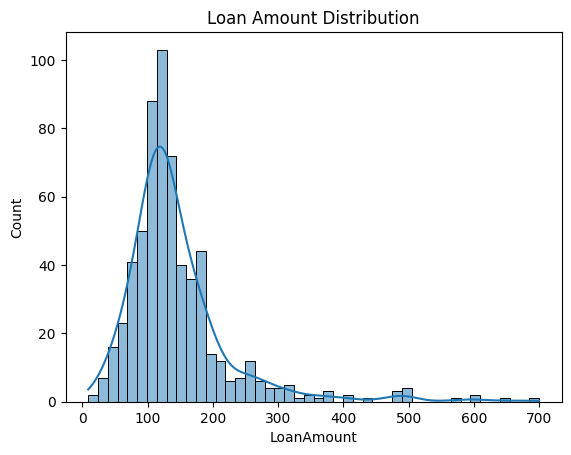

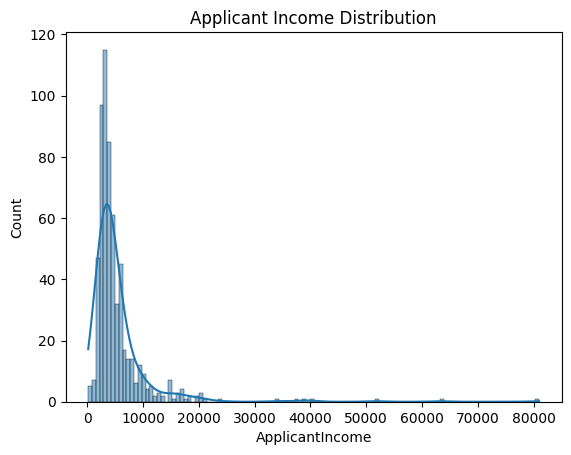

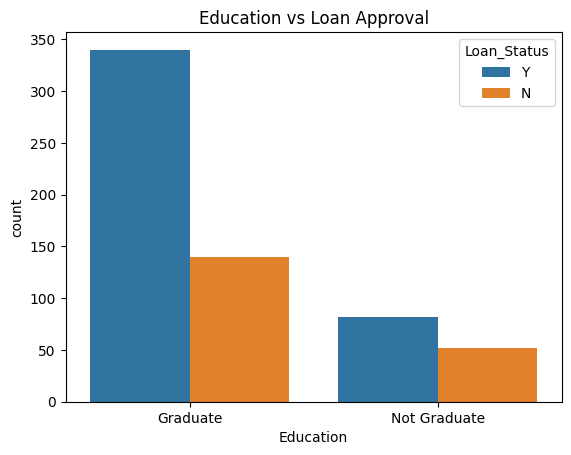

Accuracy: 0.7886178861788617
Confusion Matrix:
 [[18 25]
 [ 1 79]]


In [3]:
# ==================================
# Credit Risk Prediction Project
# ==================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("loan.csv")

# -----------------------------
# Handle Missing Values
# -----------------------------
df.fillna(df.mode().iloc[0], inplace=True)

# -----------------------------
# Exploratory Data Analysis
# -----------------------------

# Loan Amount Distribution
sns.histplot(df["LoanAmount"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

# Applicant Income Distribution
sns.histplot(df["ApplicantIncome"], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

# Education vs Loan Status
sns.countplot(x="Education", hue="Loan_Status", data=df)
plt.title("Education vs Loan Approval")
plt.show()

# -----------------------------
# Encoding Categorical Columns
# -----------------------------
le = LabelEncoder()
for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

# -----------------------------
# Feature Selection
# -----------------------------
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Model Training
# -----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
